# 한글 워드클라우드

In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics
import yfinance as yf
import tensorflow as tf

from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.python.keras.utils import np_utils
from keras.datasets import mnist
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from prophet.plot import add_changepoints_to_plot, plot_plotly, plot_components_plotly
from prophet  import Prophet
from openpyxl import load_workbook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier


# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

2026-02-23 20:46:04.666096: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## Okt

from konlpy.tag import Okt

okt = Okt()
text = "자연어 처리는 정말 재미있어요!"
print(okt.morphs(text))       # 형태소 분리
print(okt.pos(text))          # 품사 태깅
print(okt.nouns(text))        # 명사만 추출

['자연어', '처리', '는', '정말', '재미있어요', '!']
[('자연어', 'Noun'), ('처리', 'Noun'), ('는', 'Josa'), ('정말', 'Noun'), ('재미있어요', 'Adjective'), ('!', 'Punctuation')]
['자연어', '처리', '정말']


In [3]:
## Hannanum

from konlpy.tag import Hannanum

h = Hannanum()
text = "자연어 처리는 정말 재미있어요!"
print(h.morphs(text))       # 형태소 분리
print(h.pos(text))          # 품사 태깅
print(h.nouns(text))        # 명사만 추출

['자연어', '처리', '는', '정말', '재미있', '어', '요', '!']
[('자연어', 'N'), ('처리', 'N'), ('는', 'J'), ('정말', 'M'), ('재미있', 'P'), ('어', 'E'), ('요', 'J'), ('!', 'S')]
['자연어', '처리']


In [5]:
from collections import Counter
from wordcloud import WordCloud

# 1. 형태소 분석기 객체 생성
okt = Okt()

# 2. 샘플 텍스트 분석
text = "파이썬 워드클라우드 정말 재밌어요! 주피터 노트북 최고!, 워드 클라우드 실행해 봅시다"
nouns = okt.nouns(text)  # 명사만 추출

# 3. 빈도수 계산 (설치 필요 없는 내장 모듈 사용)
counts = Counter(nouns)
print(counts) # 결과 확인용

Counter({'워드': 2, '클라우드': 2, '파이썬': 1, '정말': 1, '주피터': 1, '노트북': 1, '최고': 1, '실행': 1})


1. 데이터 읽어오기
2. Hannanum().nouns()  로 명사 추출 (또는 Okt())
3. Counter()로 빈도 계산
4. 폰트 설정
5. 워드클라우드 생성 (   wcs.generate_from_frequencies(변수)   )
6. 워드클라우드 이미지 출력 (  plt.imshow(구름)  )

In [6]:
txt = open('../../data/wordcloud_001.txt','rt', encoding='UTF-8').read()

txt

'닭이 너무 맛있어요 최고!! 육질이 살아있음\n배송도 빠르고 상품도 좋습니다. ^^\n기가막히게 맛있습니다. 사장님 감사합니다.\n닭이 너무 작아요! 양이 작은 편인데도 부족하네요. ><\n완전 만족합니다. 재구매 각이네요.\n삼계탕에 넣었는데 양이 기대 이하네요...\n배송이 늦었네요. 보내주신 아이스팩이 터져서 치운다고 고생했네요. 포장에 신경써야 할듯...\n닭이 엄청 크고 실하네요. 들어갈만한 냄비가 없어서 큰 냄비를 샀네요. 맛도 좋습니다.\n아이스박스가 터져서 왔네요. 비닐도 벗겨지고... 다시 구매하고 싶지 않네요. 그나마 닭이 상하지 않은게 다행인듯...\n닭에 기름이 너무 많네요. 기름제거가 너무 힘들었네요. ㅠㅠ\n살이 너무 퍽퍽해요. 요리를 잘 못한 건지 닭 자체가 그런건지 잘 모르겠네요.\n너무 신선합니다. 살도 너무 부드러워요. 오랜만에 가족들과 맛있는 삼계탕 해먹었네요. 감사합니다.\n가격이 저렴함에도 불구하고, 닭이 너무 신선하고 맛있네요. 담에 또 구매할 생각입니다.\n싼 게 비지떡이라더니 그 말이 딱 맞네요. 저한텐 닭이 너무 작네요. 실망입니다.\n착한 가격에 뽑기가 잘된 건지 저는 너무 맛있게 잘 먹었습니다. 만족합니다. ^0^\n씻은 뒤에 에어프라이에 소금만 쳐서 돌려 먹었는데 남편도, 아이도 너무 잘 먹었습니다. 양이 좀 작은 건 아쉬웠네요.\n만족해요 만족해요 만족해요 만족해요 ^-^\n생닭인데 피가 제대로 안씻긴 듯 합니다. 씻는데 피가 자꾸 나와서 무서웠네요.\n배송하면서 아이스박스가 터진건지 보낼 때부터 이랬던 건지... 닭도 상해서 왔네요. 환불 요청합니다.\n두 마리를 시켰는데 한 마리는 큰 데 나머지 한 마리는 눈에 띄게 작네요. 가격이 싸서 그렇겠죠?\n좋아요~ 저렴한 가격에 잘 산 것 같네요. :)\n어머니가 담에는 좀 더 큰 닭으로 사라고 하시네요. 맛은 있는데 양이 작습니다. ㅡㅡ...\n맛있게 먹었습니다. 배송도 빠른 편이네요.\n싱싱합니다. 추천 박을게요.\n백숙용으로는 적합하지 않은 것 같습니다.

In [7]:
# txt 문서에서 명사만 추출하기
n1 = Okt().nouns(txt)
n1

['닭',
 '최고',
 '육질',
 '배송',
 '상품',
 '기',
 '사장',
 '닭',
 '양',
 '완전',
 '네',
 '삼계탕',
 '양',
 '기대',
 '이하',
 '배송',
 '아이스팩',
 '고생',
 '포장',
 '신경',
 '닭',
 '냄비',
 '냄비',
 '맛',
 '아이스박스',
 '비닐',
 '다시',
 '구매',
 '닭',
 '상하',
 '다행',
 '듯',
 '닭',
 '기름',
 '기름',
 '거가',
 '살이',
 '퍽퍽해',
 '요리',
 '못',
 '닭',
 '자체',
 '건',
 '살',
 '만',
 '가족',
 '삼계탕',
 '해',
 '가격',
 '불구',
 '닭',
 '담',
 '또',
 '구매',
 '생각',
 '게',
 '비지',
 '떡',
 '더니',
 '그',
 '말',
 '한텐',
 '닭',
 '실망',
 '가격',
 '뽑기',
 '저',
 '뒤',
 '에어',
 '프라이',
 '소금',
 '남편',
 '아이',
 '양',
 '좀',
 '건',
 '생닭',
 '피',
 '제대로',
 '듯',
 '피',
 '자꾸',
 '배송',
 '아이스박스',
 '때',
 '닭',
 '상해',
 '환불',
 '요청',
 '두',
 '마리',
 '마리',
 '데',
 '나머지',
 '마리',
 '눈',
 '가격',
 '가격',
 '산',
 '것',
 '어머니',
 '담',
 '좀',
 '더',
 '닭',
 '사라',
 '맛',
 '양',
 '배송',
 '편이',
 '추천',
 '백숙',
 '용',
 '것',
 '마트',
 '닭',
 '양도',
 '저',
 '것',
 '번창',
 '밥솥',
 '닭',
 '죽',
 '해',
 '처음',
 '실패',
 '안',
 '것',
 '쫄깃쫄깃',
 '육질',
 '끝내',
 '주네',
 '예정',
 '좀',
 '것',
 '맛',
 '요리',
 '안해',
 '겉모습',
 '마트',
 '닭',
 '별',
 '차이',
 '못']

In [9]:
# 글자수가 2개 이상인 단어만 필터링
n2 = [i for i in n1 if len(i) >=2]
n2

['최고',
 '육질',
 '배송',
 '상품',
 '사장',
 '완전',
 '삼계탕',
 '기대',
 '이하',
 '배송',
 '아이스팩',
 '고생',
 '포장',
 '신경',
 '냄비',
 '냄비',
 '아이스박스',
 '비닐',
 '다시',
 '구매',
 '상하',
 '다행',
 '기름',
 '기름',
 '거가',
 '살이',
 '퍽퍽해',
 '요리',
 '자체',
 '가족',
 '삼계탕',
 '가격',
 '불구',
 '구매',
 '생각',
 '비지',
 '더니',
 '한텐',
 '실망',
 '가격',
 '뽑기',
 '에어',
 '프라이',
 '소금',
 '남편',
 '아이',
 '생닭',
 '제대로',
 '자꾸',
 '배송',
 '아이스박스',
 '상해',
 '환불',
 '요청',
 '마리',
 '마리',
 '나머지',
 '마리',
 '가격',
 '가격',
 '어머니',
 '사라',
 '배송',
 '편이',
 '추천',
 '백숙',
 '마트',
 '양도',
 '번창',
 '밥솥',
 '처음',
 '실패',
 '쫄깃쫄깃',
 '육질',
 '끝내',
 '주네',
 '예정',
 '요리',
 '안해',
 '겉모습',
 '마트',
 '차이']

In [11]:
# 명사별 빈도
cnt = Counter(n2)
cnt

Counter({'배송': 4,
         '가격': 4,
         '마리': 3,
         '육질': 2,
         '삼계탕': 2,
         '냄비': 2,
         '아이스박스': 2,
         '구매': 2,
         '기름': 2,
         '요리': 2,
         '마트': 2,
         '최고': 1,
         '상품': 1,
         '사장': 1,
         '완전': 1,
         '기대': 1,
         '이하': 1,
         '아이스팩': 1,
         '고생': 1,
         '포장': 1,
         '신경': 1,
         '비닐': 1,
         '다시': 1,
         '상하': 1,
         '다행': 1,
         '거가': 1,
         '살이': 1,
         '퍽퍽해': 1,
         '자체': 1,
         '가족': 1,
         '불구': 1,
         '생각': 1,
         '비지': 1,
         '더니': 1,
         '한텐': 1,
         '실망': 1,
         '뽑기': 1,
         '에어': 1,
         '프라이': 1,
         '소금': 1,
         '남편': 1,
         '아이': 1,
         '생닭': 1,
         '제대로': 1,
         '자꾸': 1,
         '상해': 1,
         '환불': 1,
         '요청': 1,
         '나머지': 1,
         '어머니': 1,
         '사라': 1,
         '편이': 1,
         '추천': 1,
         '백숙': 1,
         '양도': 1,

In [12]:
# 워드클라우드용 폰트 설정
wcs = WordCloud(font_path = '/usr/share/fonts/truetype/nanum/NanumBarunpenR.ttf', background_color = 'white', colormap='RdBu')

In [13]:
# 단어별 빈도로 워드클라우드 생성
cloud = wcs.generate_from_frequencies(cnt)

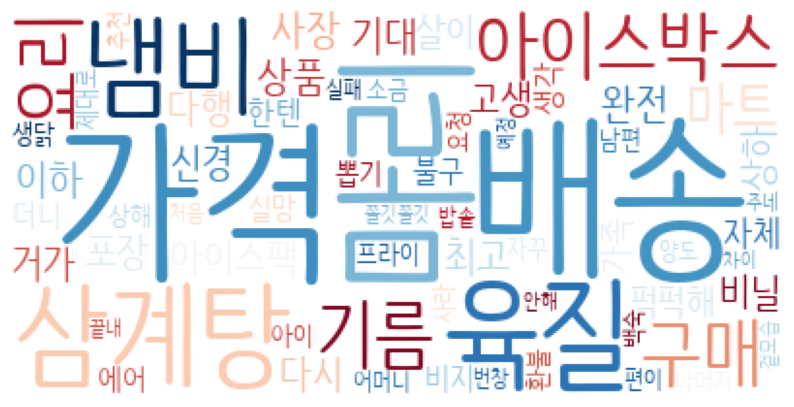

In [14]:
# 워드클라우드 그리기
import matplotlib.pyplot as plt
plt.figure(figsize = (10,7))
plt.axis('off')
plt.imshow(cloud)
# plt.savefig('../../data/wordcloud_001_image.png')